In [2]:
!pip install pandas numpy matplotlib seaborn

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")

Explore Dataset 1

In [4]:
df1 = pd.read_csv("Unemployment in India.csv")
df2 = pd.read_csv("Unemployment_Rate_upto_11_2020.csv")

print("Dataset 1 Shape:", df1.shape)
print("Dataset 2 Shape:", df2.shape)

Dataset 1 Shape: (768, 7)
Dataset 2 Shape: (267, 9)


In [5]:
df1.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [7]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [8]:
df1.isnull().sum()

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

In [9]:
df1.columns = df1.columns.str.strip()
df1.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [10]:
df1['Date'] = pd.to_datetime(df1['Date'])

df1['Year'] = df1['Date'].dt.year
df1['Month'] = df1['Date'].dt.month

df1.head()

C:\Users\AJAY KUMAR\AppData\Local\Temp\ipykernel_18752\2497114852.py:1: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df1['Date'] = pd.to_datetime(df1['Date'])


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Year,Month
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,2019.0,5.0
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,2019.0,6.0
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,2019.0,7.0
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,2019.0,8.0
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,2019.0,9.0


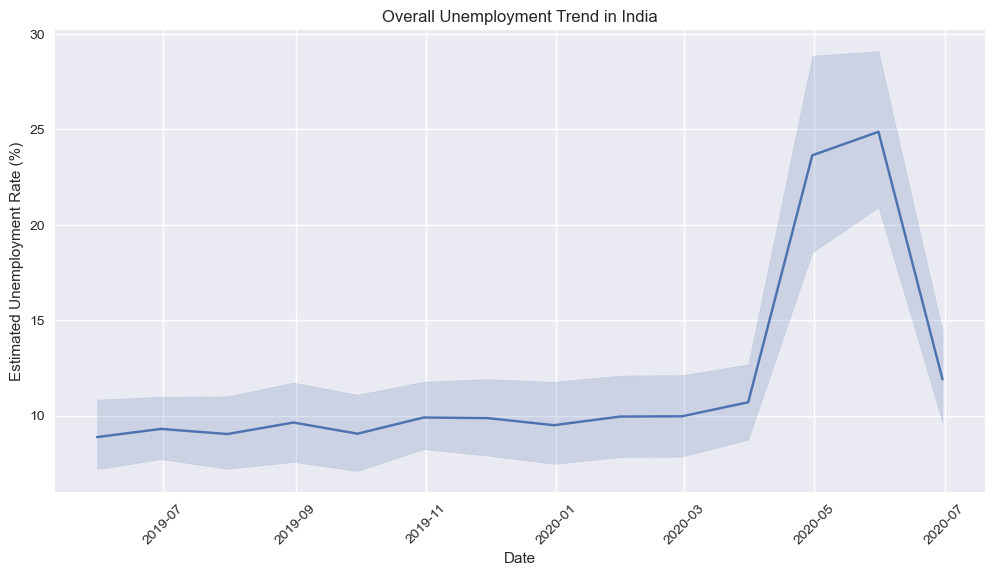

In [11]:
plt.figure(figsize=(12,6))
sns.lineplot(data=df1,
             x="Date",
             y="Estimated Unemployment Rate (%)")
plt.title("Overall Unemployment Trend in India")
plt.xticks(rotation=45)
plt.show()

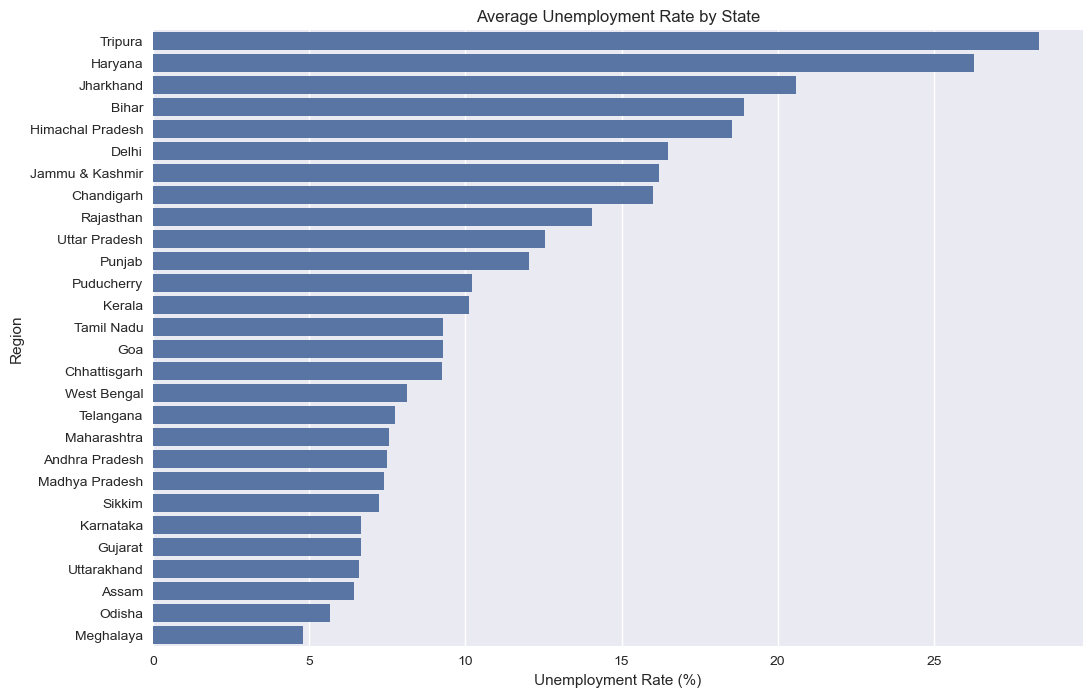

In [12]:
state_avg = df1.groupby("Region")["Estimated Unemployment Rate (%)"].mean().sort_values(ascending=False)

plt.figure(figsize=(12,8))
sns.barplot(x=state_avg.values, y=state_avg.index)
plt.title("Average Unemployment Rate by State")
plt.xlabel("Unemployment Rate (%)")
plt.show()

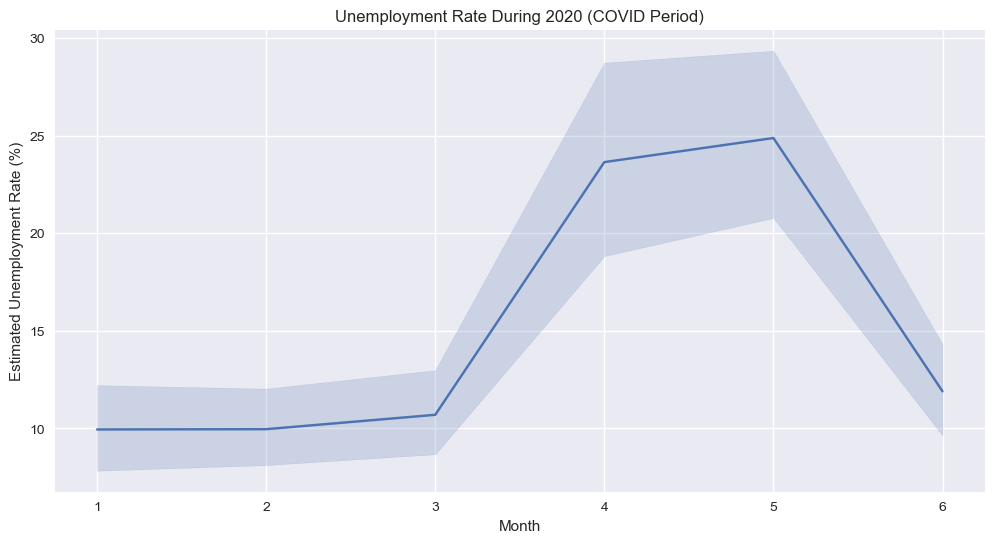

In [13]:
covid_data = df1[df1["Year"] == 2020]

plt.figure(figsize=(12,6))
sns.lineplot(data=covid_data,
             x="Month",
             y="Estimated Unemployment Rate (%)")
plt.title("Unemployment Rate During 2020 (COVID Period)")
plt.show()

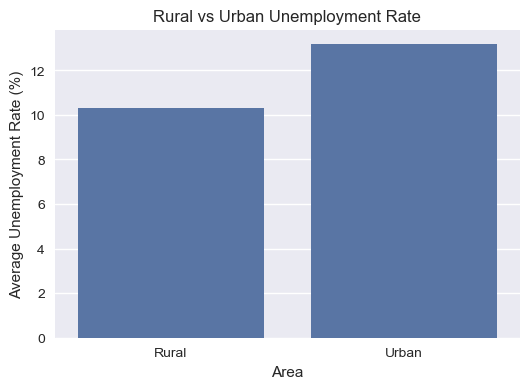

In [14]:
area_avg = df1.groupby("Area")["Estimated Unemployment Rate (%)"].mean()

plt.figure(figsize=(6,4))
sns.barplot(x=area_avg.index, y=area_avg.values)
plt.title("Rural vs Urban Unemployment Rate")
plt.ylabel("Average Unemployment Rate (%)")
plt.show()

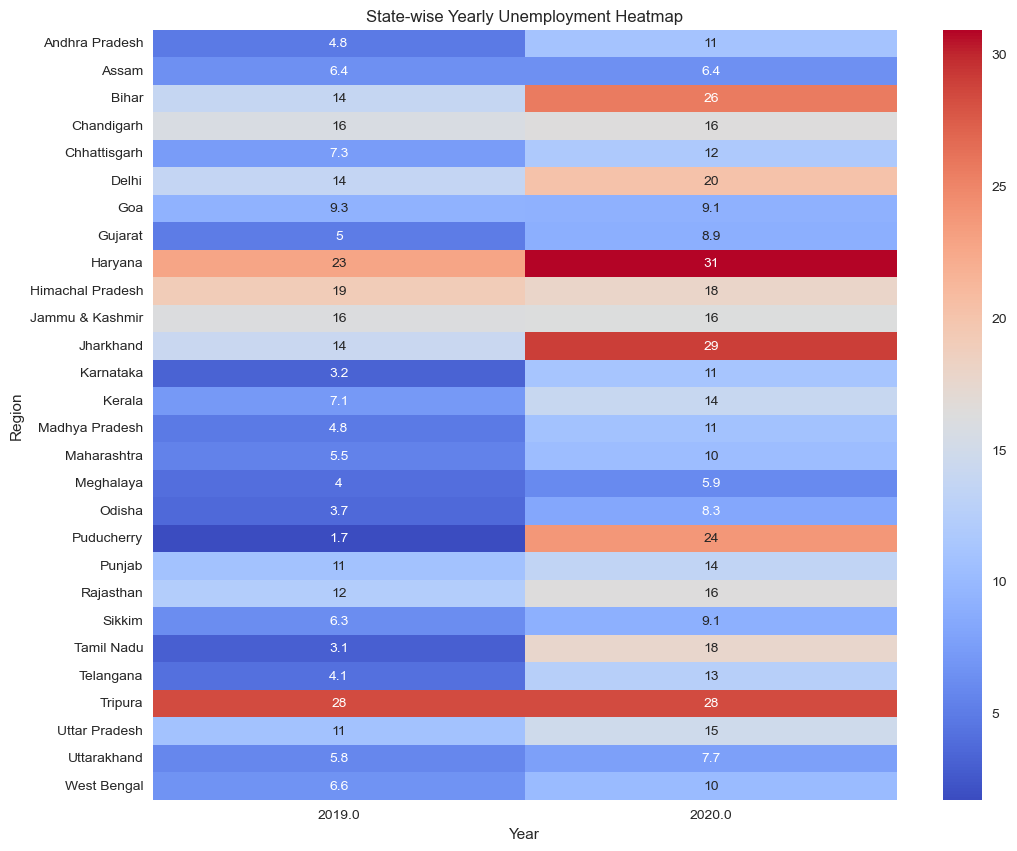

In [15]:
pivot_table = df1.pivot_table(
    values="Estimated Unemployment Rate (%)",
    index="Region",
    columns="Year",
    aggfunc="mean"
)

plt.figure(figsize=(12,10))
sns.heatmap(pivot_table, cmap="coolwarm", annot=True)
plt.title("State-wise Yearly Unemployment Heatmap")
plt.show()

Second Dataset Analysis COVID Detailed

In [16]:
df2.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


In [17]:
df2.columns = df2.columns.str.strip()
df2['Date'] = pd.to_datetime(df2['Date'])

df2['Year'] = df2['Date'].dt.year
df2['Month'] = df2['Date'].dt.month

df2.head()

C:\Users\AJAY KUMAR\AppData\Local\Temp\ipykernel_18752\628327116.py:2: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df2['Date'] = pd.to_datetime(df2['Date'])


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude,Year,Month
0,Andhra Pradesh,2020-01-31,M,5.48,16635535,41.02,South,15.9129,79.74,2020,1
1,Andhra Pradesh,2020-02-29,M,5.83,16545652,40.90,South,15.9129,79.74,2020,2
2,Andhra Pradesh,2020-03-31,M,5.79,15881197,39.18,South,15.9129,79.74,2020,3
3,Andhra Pradesh,2020-04-30,M,20.51,11336911,33.10,South,15.9129,79.74,2020,4
4,Andhra Pradesh,2020-05-31,M,17.43,12988845,36.46,South,15.9129,79.74,2020,5


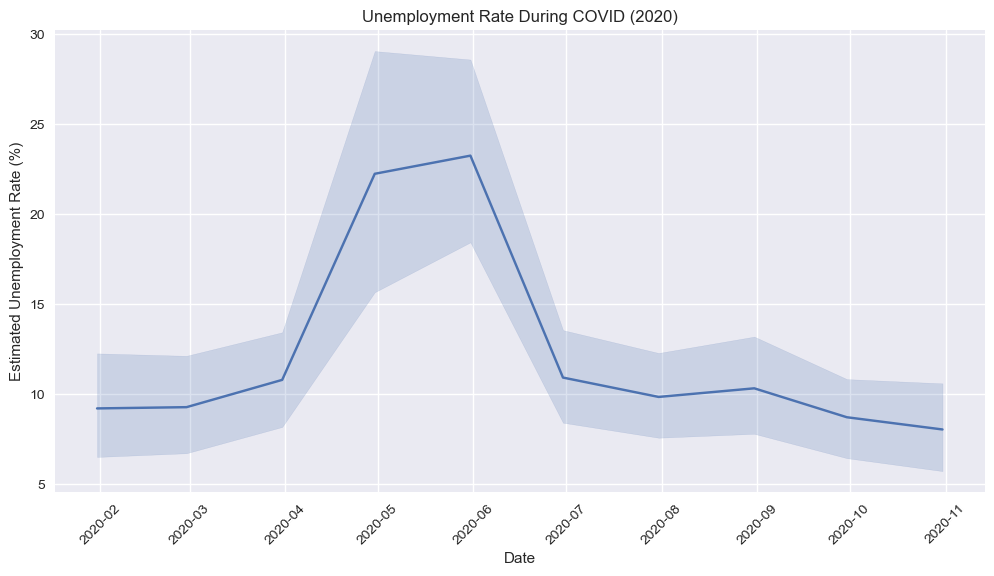

In [18]:
plt.figure(figsize=(12,6))
sns.lineplot(data=df2,
             x="Date",
             y="Estimated Unemployment Rate (%)")
plt.title("Unemployment Rate During COVID (2020)")
plt.xticks(rotation=45)
plt.show()

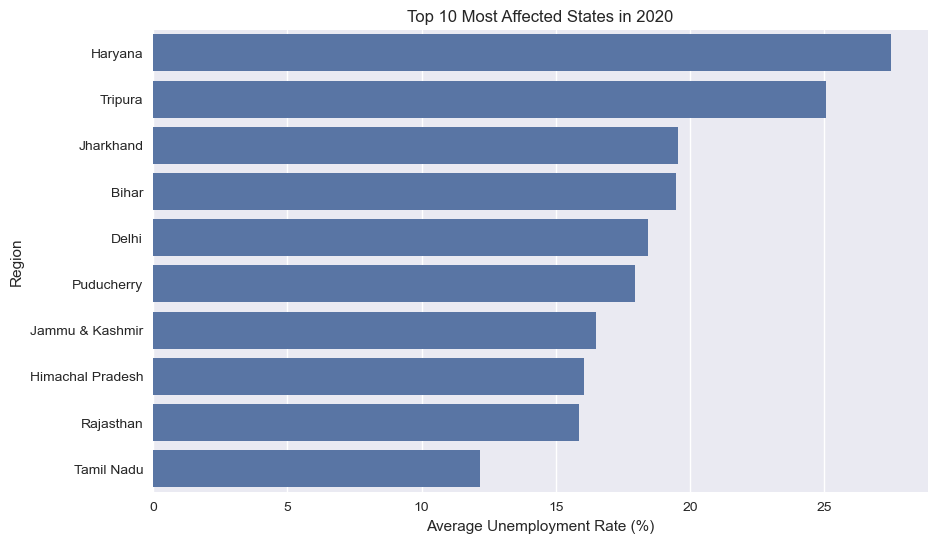

In [21]:
top_states = df2.groupby("Region")["Estimated Unemployment Rate (%)"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_states.values, y=top_states.index)
plt.title("Top 10 Most Affected States in 2020")
plt.xlabel("Average Unemployment Rate (%)")
plt.show()
